In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from sklearn import metrics

figures_dir = 'figures/comp'
figure_data_dir = 'figure_data'
os.makedirs(figures_dir, exist_ok=True)


def draw_coocc_network(ax, G_coocc, G_inter, pos, pearson_norm, title):
    nx.draw_networkx_nodes(G_coocc, pos, ax=ax, node_color='skyblue', node_size=8)
    edges = list(G_coocc.edges())
    solid_edges  = [(u, v) for u, v in edges if G_inter.has_edge(u, v)]
    dotted_edges = [(u, v) for u, v in edges if not G_inter.has_edge(u, v)]
    if solid_edges:
        nx.draw_networkx_edges(G_coocc, pos, ax=ax, edgelist=solid_edges,
            edge_color=[('blue' if pearson_norm[u, v] >= 0 else 'red') for u, v in solid_edges],
            width=[abs(pearson_norm[u, v]) * 10 for u, v in solid_edges],
            style='solid')
    if dotted_edges:
        nx.draw_networkx_edges(G_coocc, pos, ax=ax, edgelist=dotted_edges,
            edge_color=[('blue' if pearson_norm[u, v] >= 0 else 'red') for u, v in dotted_edges],
            width=[abs(pearson_norm[u, v]) * 10 for u, v in dotted_edges],
            style='dotted')
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, label='Positive co-occurrence'),
        Line2D([0], [0], color='red',  lw=2, label='Negative co-occurrence'),
        Line2D([0], [0], color='gray', lw=2, linestyle='solid',  label='In both networks'),
        Line2D([0], [0], color='gray', lw=2, linestyle='dotted', label='Only in co-occurrence'),
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=8)
    ax.set_title(title, fontsize=12)

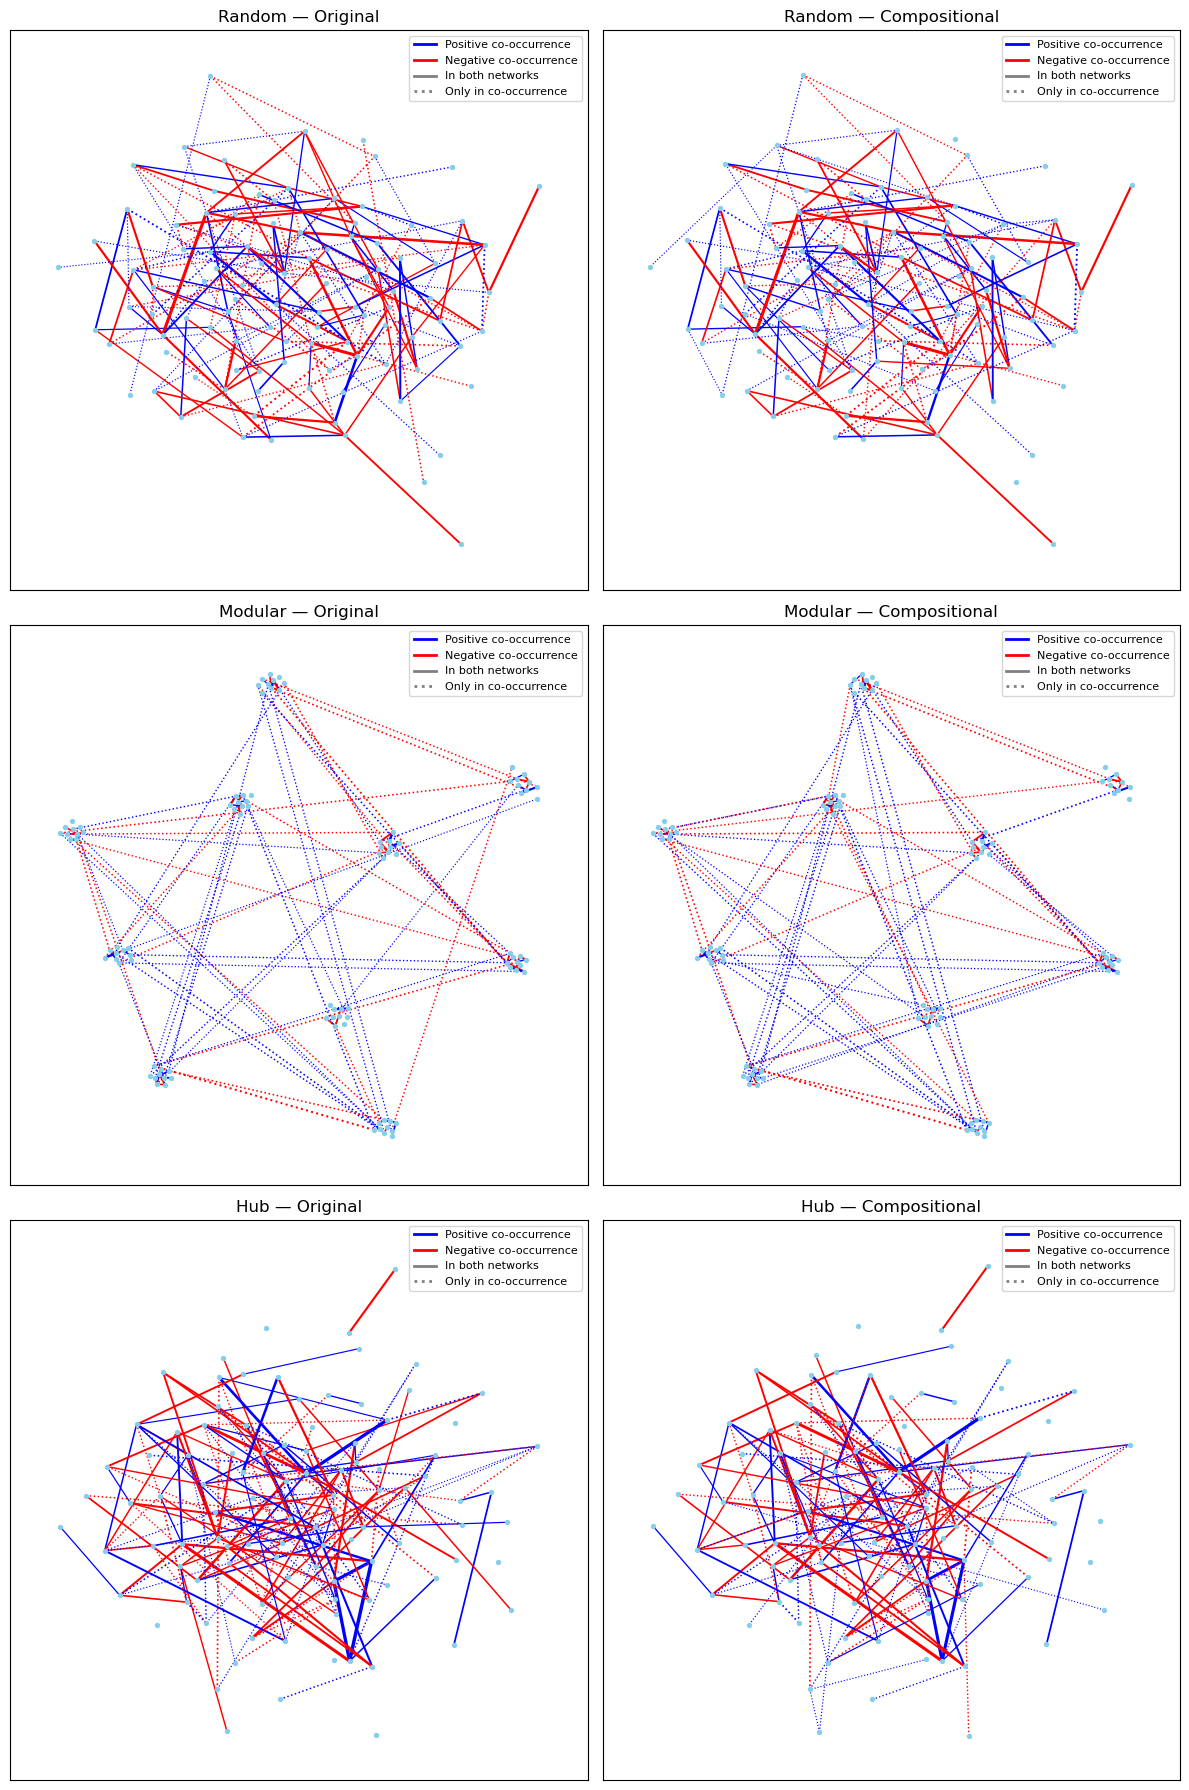

In [8]:
# Figure 1: Co-occurrence networks (rand / mod / hub) — original vs compositional

with open(f'{figure_data_dir}/rid_networks.pkl', 'rb') as f:
    d = pickle.load(f)
with open(f'{figure_data_dir}/rid_networks_comp.pkl', 'rb') as f:
    d_comp = pickle.load(f)

row_labels = ['Random', 'Modular', 'Hub']
net_keys   = ['rand', 'mod', 'hub']

fig, axes = plt.subplots(3, 2, figsize=(12, 18))

for row, (label, key) in enumerate(zip(row_labels, net_keys)):
    for col, (data, col_title, prefix) in enumerate([(d, 'Original', ''), (d_comp, 'Compositional', 'comp_')]):
        ax = axes[row, col]
        G_coocc = nx.from_numpy_array(data[f'network_{prefix}{key}'])
        G_inter = nx.from_numpy_array(data[f'{key}Mx'] != 0)
        draw_coocc_network(ax, G_coocc, G_inter,
                           data[f'pos_{key}'],
                           data[f'norm_pearson_{prefix}{key}'],
                           f'{label} — {col_title}')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_networks_comp.png'), dpi=300, bbox_inches='tight')
plt.show()

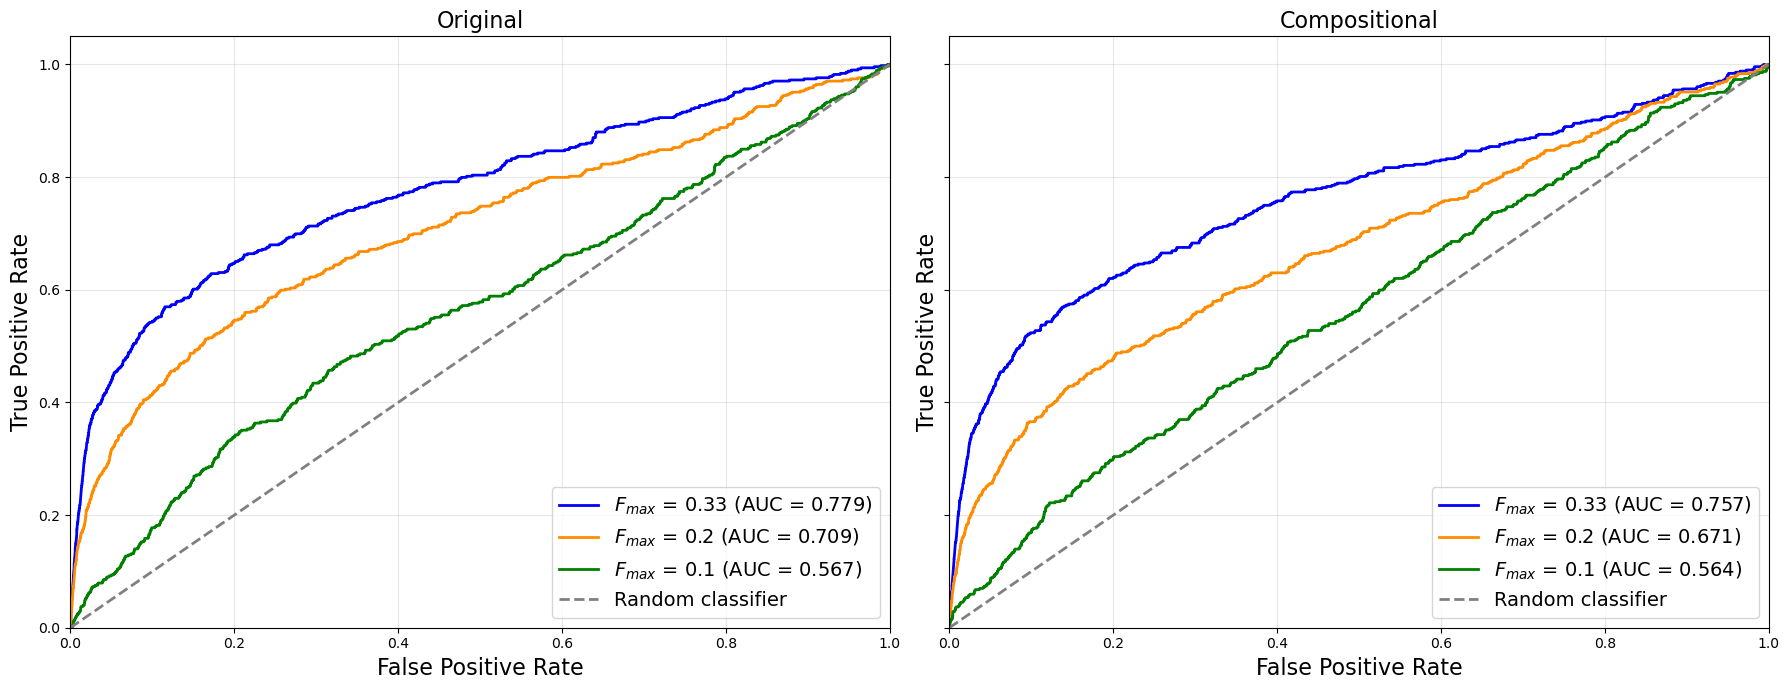

In [9]:
# Figure 2: ROC curves (random matrix, interaction strength sweep) — original vs compositional

with open(f'{figure_data_dir}/rid_roc_rand.pkl', 'rb') as f:
    d = pickle.load(f)
with open(f'{figure_data_dir}/rid_roc_rand_comp.pkl', 'rb') as f:
    d_comp = pickle.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, data, title in [(ax1, d, 'Original'), (ax2, d_comp, 'Compositional')]:
    for entry, color in zip(data['roc_data'], data['colors']):
        ax.plot(entry['fpr'], entry['tpr'], color=color, lw=2,
                label=f'$F_{{max}}$ = {np.round(entry["interactFactor"], 2)} (AUC = {entry["roc_auc"]:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='lower right', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_roc_rand_comp.png'), dpi=300, bbox_inches='tight')
plt.show()

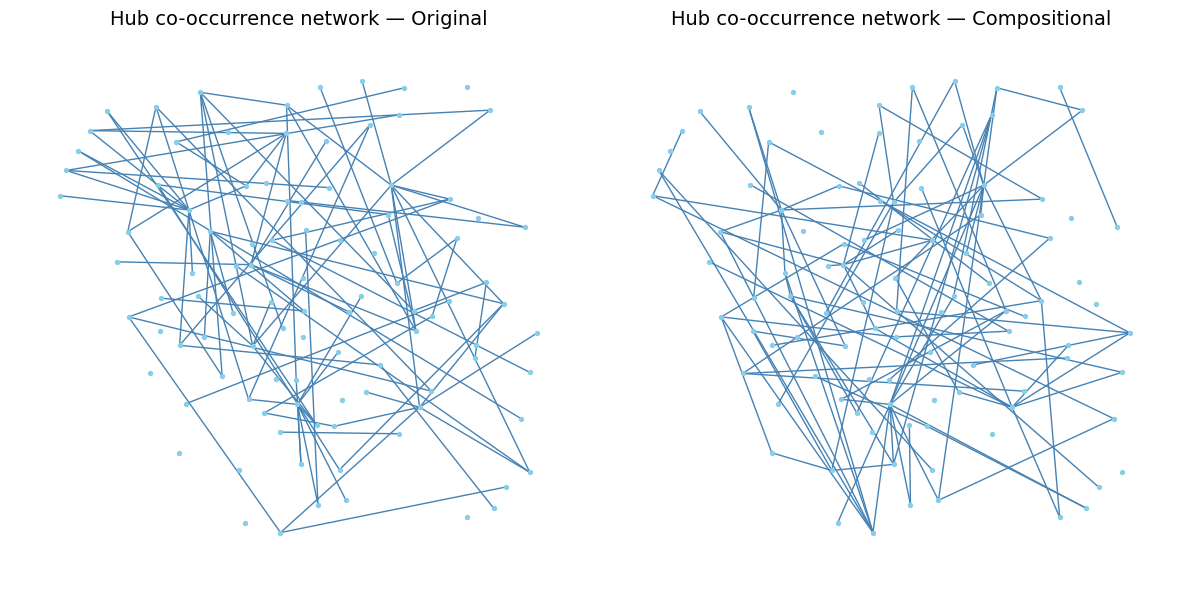

In [10]:
# Figure 3: Hub network plot — original vs compositional

with open(f'{figure_data_dir}/rh_network_plot.pkl', 'rb') as f:
    d = pickle.load(f)
with open(f'{figure_data_dir}/rh_network_plot_comp.pkl', 'rb') as f:
    d_comp = pickle.load(f)

G_hub_input = nx.from_numpy_array(d['hubMx_input'] != 0)
pos_hub_plot = nx.spring_layout(G_hub_input, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, data, title, net_key in [
    (axes[0], d,      'Original',      'network_hub_plot'),
    (axes[1], d_comp, 'Compositional', 'network_comp_hub_plot'),
]:
    G_hub_result = nx.from_numpy_array(data[net_key])
    nx.draw(G_hub_result, pos_hub_plot, ax=ax, with_labels=False,
            node_color='skyblue', node_size=8, edge_color='steelblue')
    ax.set_title(f'Hub co-occurrence network — {title}', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_hub_network_comp.png'), dpi=300, bbox_inches='tight')
plt.show()

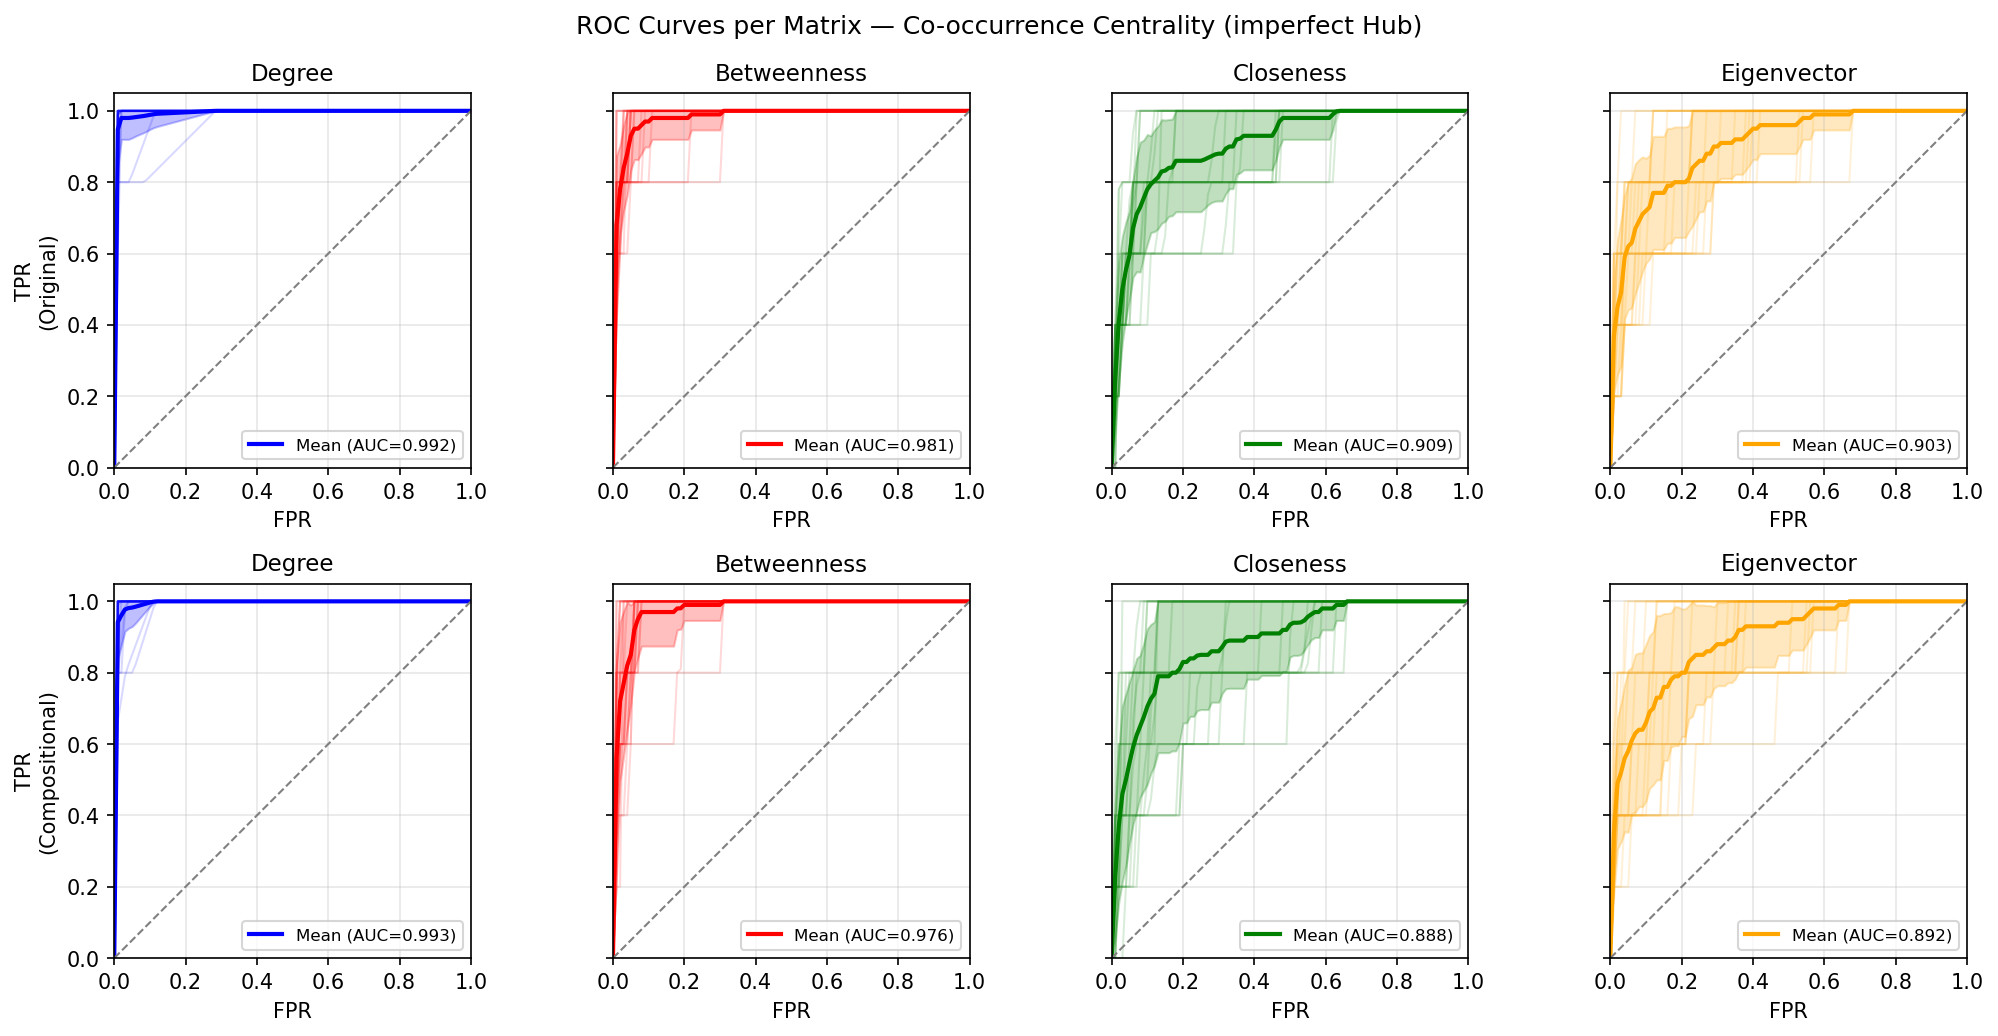

In [11]:
# Figure 4: Hub centrality ROC (imperfect hub) — original vs compositional

with open(f'{figure_data_dir}/rh_roc_imperfect.pkl', 'rb') as f:
    d = pickle.load(f)
with open(f'{figure_data_dir}/rh_roc_imperfect_comp.pkl', 'rb') as f:
    d_comp = pickle.load(f)

metric_names = d['metric_names']
colors_hub   = d['colors']
base_fpr     = d['base_fpr']

fig, axes = plt.subplots(2, len(metric_names), figsize=(14, 7), sharey=True, dpi=150)

for row, (data, row_label, tprs_key) in enumerate([
    (d,      'Original',      'tprs_per_metric'),
    (d_comp, 'Compositional', 'tprs_per_comp_metric'),
]):
    for col, (metric_name, color) in enumerate(zip(metric_names, colors_hub)):
        ax = axes[row, col]
        tprs_arr = np.array(data[tprs_key][metric_name])
        mean_tpr = tprs_arr.mean(axis=0)
        std_tpr  = tprs_arr.std(axis=0)
        mean_auc = metrics.auc(base_fpr, mean_tpr)

        for tpr_j in tprs_arr:
            ax.plot(base_fpr, tpr_j, color=color, alpha=0.15, lw=1)
        ax.plot(base_fpr, mean_tpr, color=color, lw=2, label=f'Mean (AUC={mean_auc:.3f})')
        ax.fill_between(base_fpr,
                        np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1),
                        color=color, alpha=0.25)
        ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
        ax.set_title(metric_name.title(), fontsize=11)
        ax.set_xlabel('FPR', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'TPR\n({row_label})', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves per Matrix — Co-occurrence Centrality (imperfect Hub)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_hub_roc_imperfect_comp.png'), dpi=300, bbox_inches='tight')
plt.show()

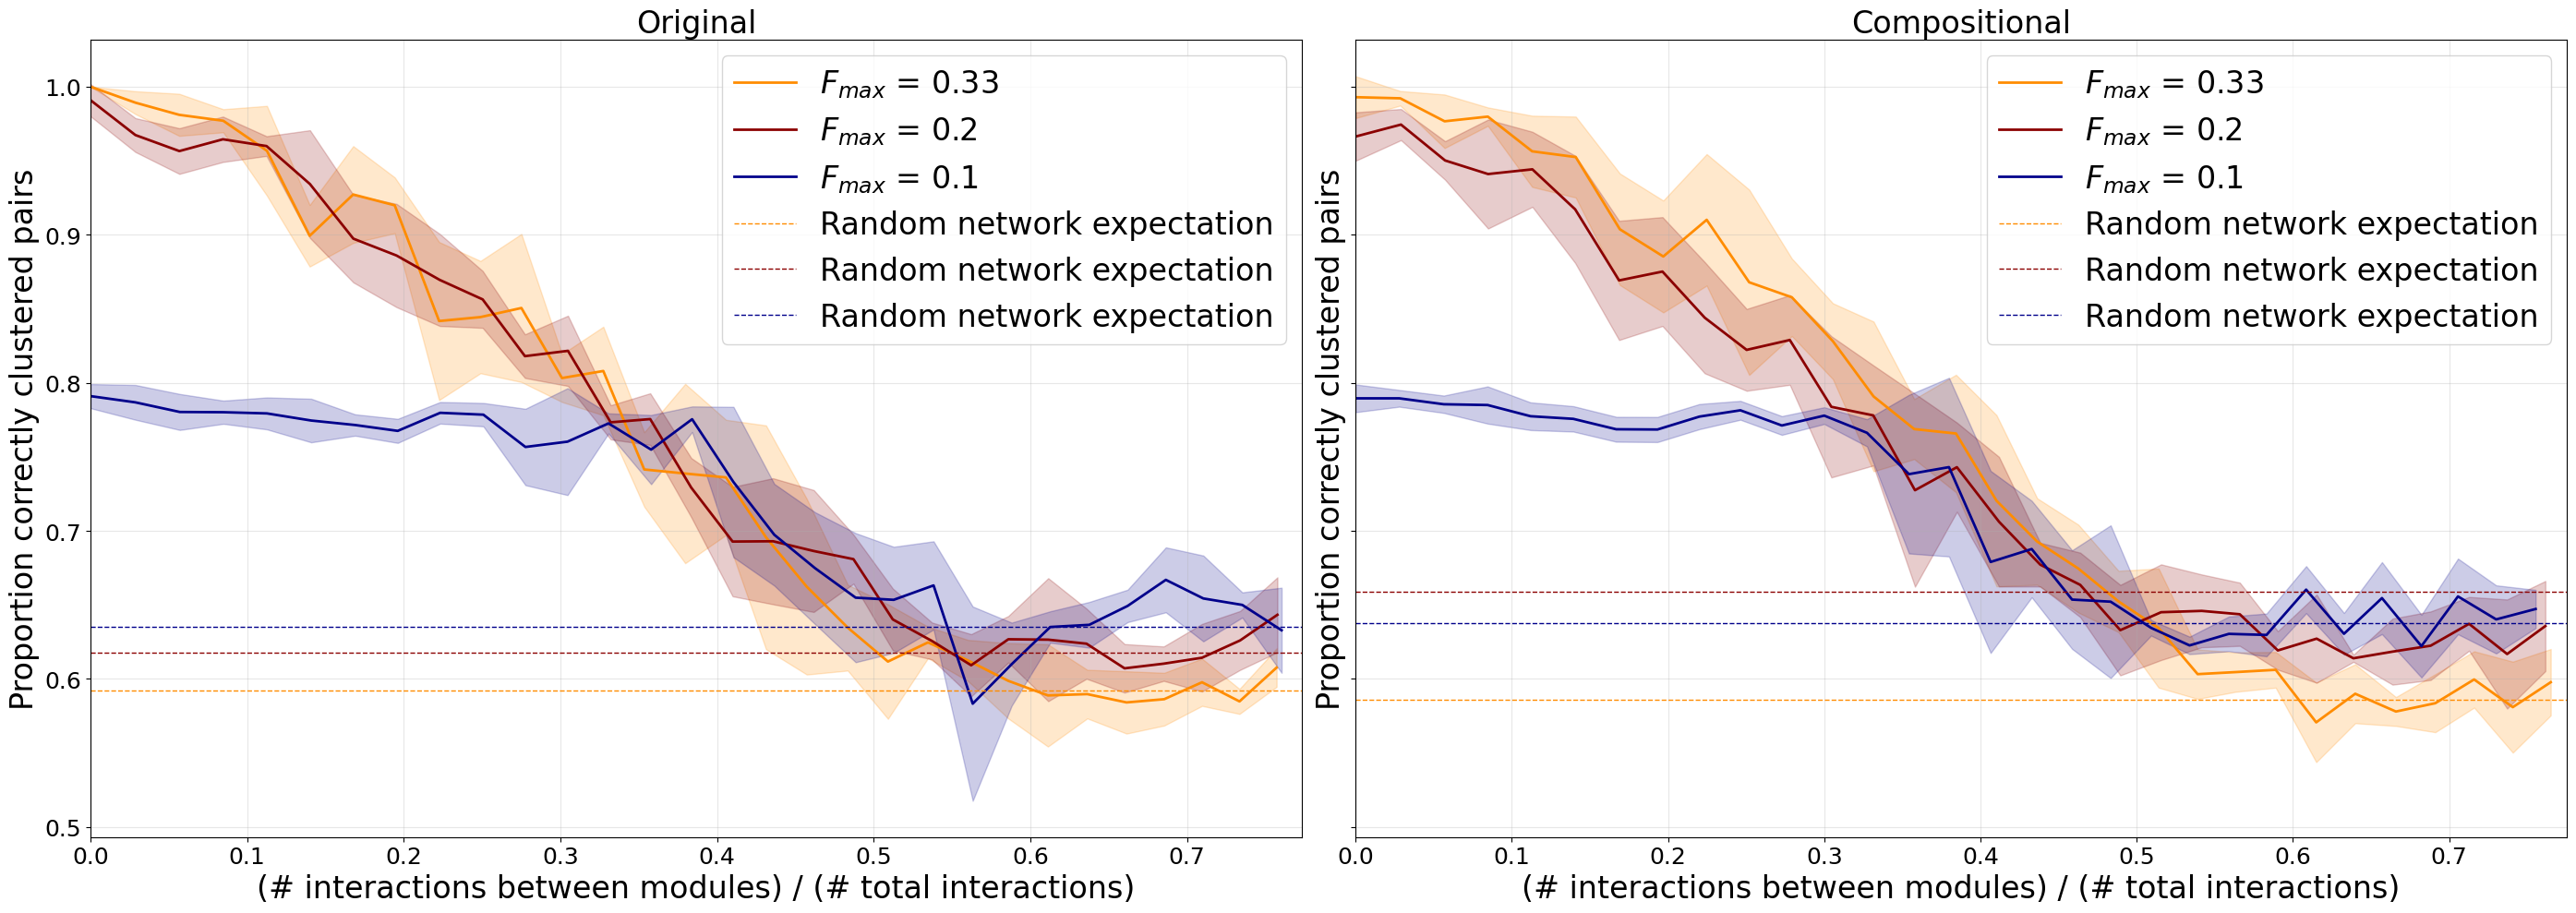

In [12]:
# Figure 5: Cluster correctness vs modularity — original vs compositional

with open(f'{figure_data_dir}/mcc_cluster_correctness.pkl', 'rb') as f:
    d = pickle.load(f)
with open(f'{figure_data_dir}/mcc_cluster_correctness_comp.pkl', 'rb') as f:
    d_comp = pickle.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 10), sharey=True)

for ax, data, title, ec_key, cc_key, r3_key, r5_key, r10_key in [
    (ax1, d,      'Original',
     'edgeCounts',      'correct_clust_res',      'rand_prop_correct_3',      'rand_prop_correct_5',      'rand_prop_correct_10'),
    (ax2, d_comp, 'Compositional',
     'edgeCounts_comp', 'correct_clust_res_comp',  'rand_comp_prop_correct_3', 'rand_comp_prop_correct_5', 'rand_comp_prop_correct_10'),
]:
    edgeCounts        = data[ec_key]
    correct_clust_res = data[cc_key]
    interactFactorL   = data['interactFactorL']
    maxEBetween       = data['maxEBetween']
    rand_prop_correct_3  = data[r3_key]
    rand_prop_correct_5  = data[r5_key]
    rand_prop_correct_10 = data[r10_key]

    total_edges     = edgeCounts[:, 0, :, :] + edgeCounts[:, 2, :, :]
    edge_proportion = edgeCounts[:, 2, :, :] / total_edges

    for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
        x_mean = np.mean(edge_proportion[:, i, :], axis=-1)
        y_mean = np.mean(correct_clust_res[:, 5, i, :], axis=-1)
        y_std  = np.std(correct_clust_res[:, 5, i, :], axis=-1)
        ax.plot(x_mean, y_mean, color=color, lw=2,
                label=f'$F_{{max}}$ = {np.round(interactFactorL[i], 2)}')
        ax.fill_between(x_mean, y_mean - y_std, y_mean + y_std, color=color, alpha=0.2)

    ax.set_xlim(np.min(edge_proportion), np.max(edge_proportion))
    ax.hlines(rand_prop_correct_3,  xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--',
              label='Random network expectation')
    ax.hlines(rand_prop_correct_5,  xmin=0, xmax=maxEBetween, color='darkred',    lw=1, linestyle='--',
              label='Random network expectation')
    ax.hlines(rand_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue',   lw=1, linestyle='--',
              label='Random network expectation')
    ax.set_xlabel('(# interactions between modules) / (# total interactions)', fontsize=24)
    ax.set_ylabel('Proportion correctly clustered pairs', fontsize=24)
    ax.set_title(title, fontsize=24)
    ax.legend(fontsize=24)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=18)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_mcc_cluster_correctness_comp.png'), dpi=300, bbox_inches='tight')
plt.show()